In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score,recall_score,classification_report
import seaborn as sns
from sklearn.preprocessing import StandardScaler,LabelEncoder
import matplotlib.pyplot as plt
import xgboost
from xgboost import XGBClassifier

In [2]:
weather=pd.read_csv("weather_forecast_data.csv")

In [4]:
weather

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain
...,...,...,...,...,...,...
2495,21.791602,45.270902,11.807192,55.044682,1017.686181,no rain
2496,27.558479,46.481744,10.884915,39.715133,1008.590961,no rain
2497,28.108274,43.817178,2.897128,75.842952,999.119187,no rain
2498,14.789275,57.908105,2.374717,2.378743,1046.501875,no rain


In [5]:
# describe
weather.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [8]:
weather.dtypes

Temperature    float64
Humidity       float64
Wind_Speed     float64
Cloud_Cover    float64
Pressure       float64
Rain            object
dtype: object

In [13]:
numCols=weather.select_dtypes(include=['number']).columns.tolist()
numCols

['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure']

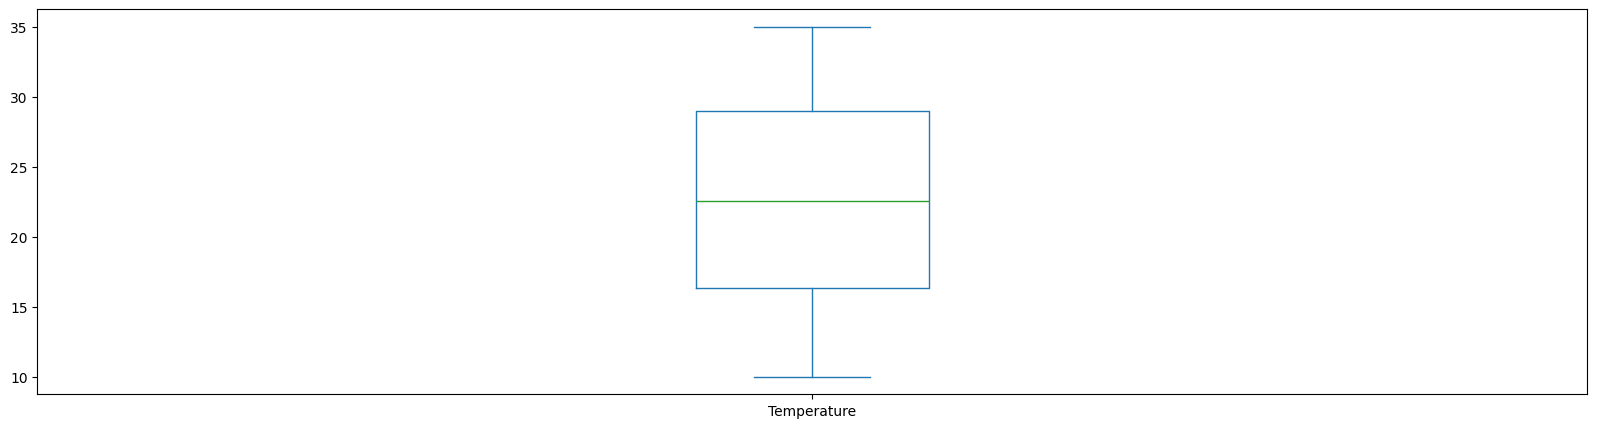

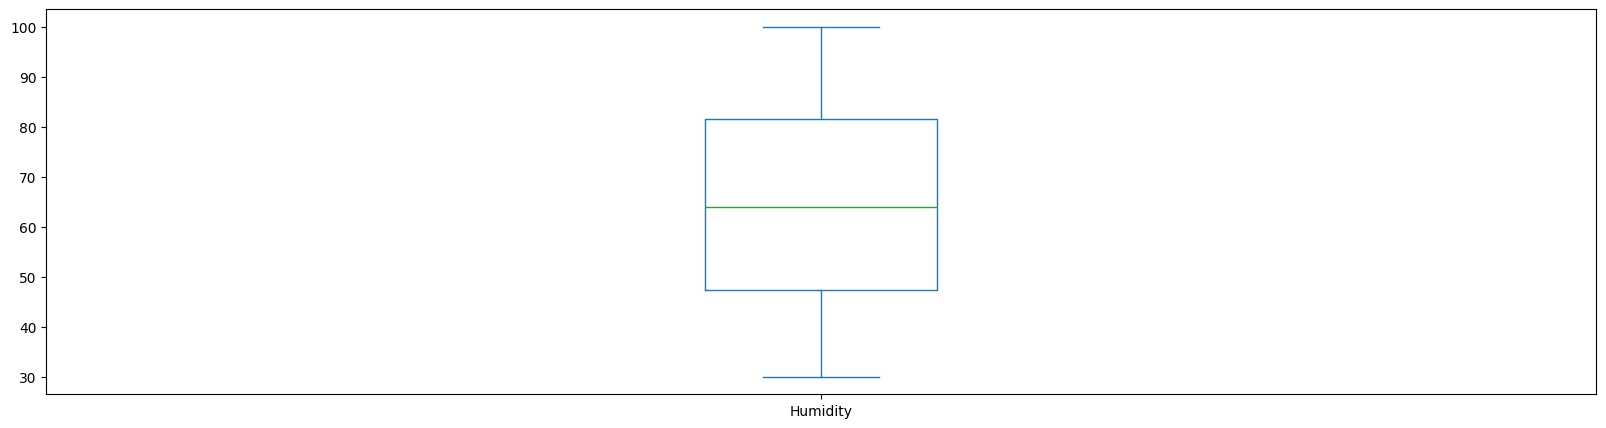

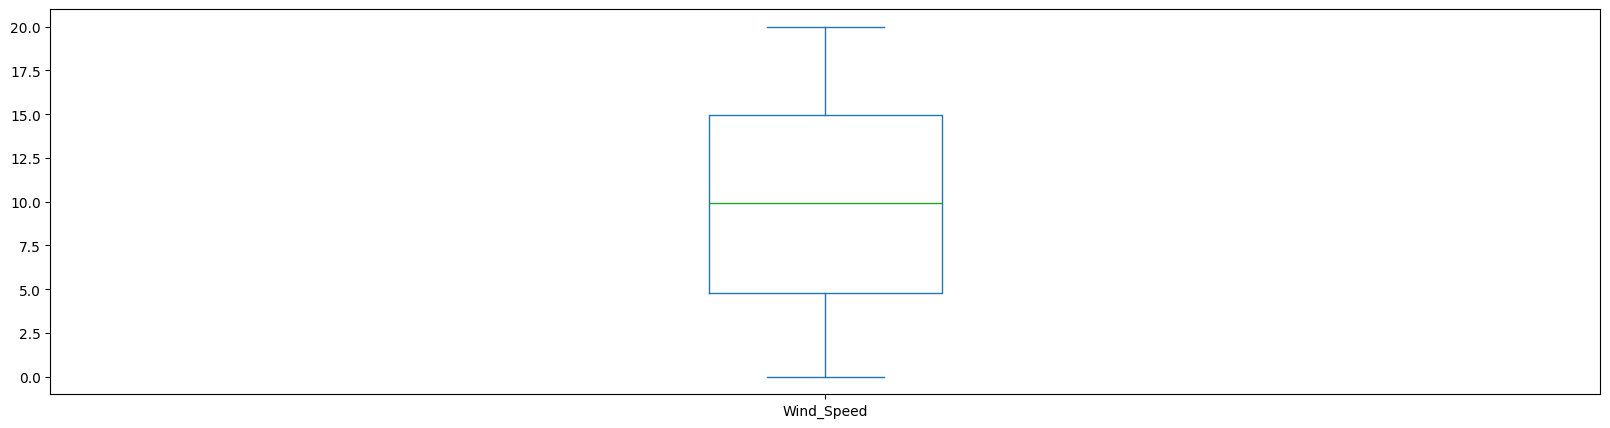

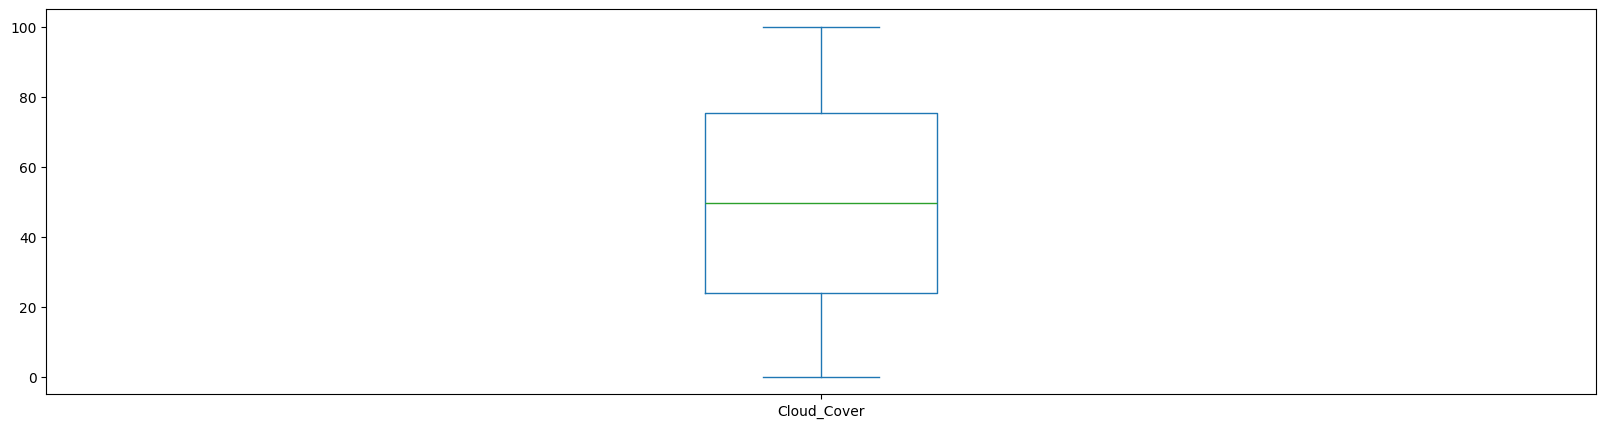

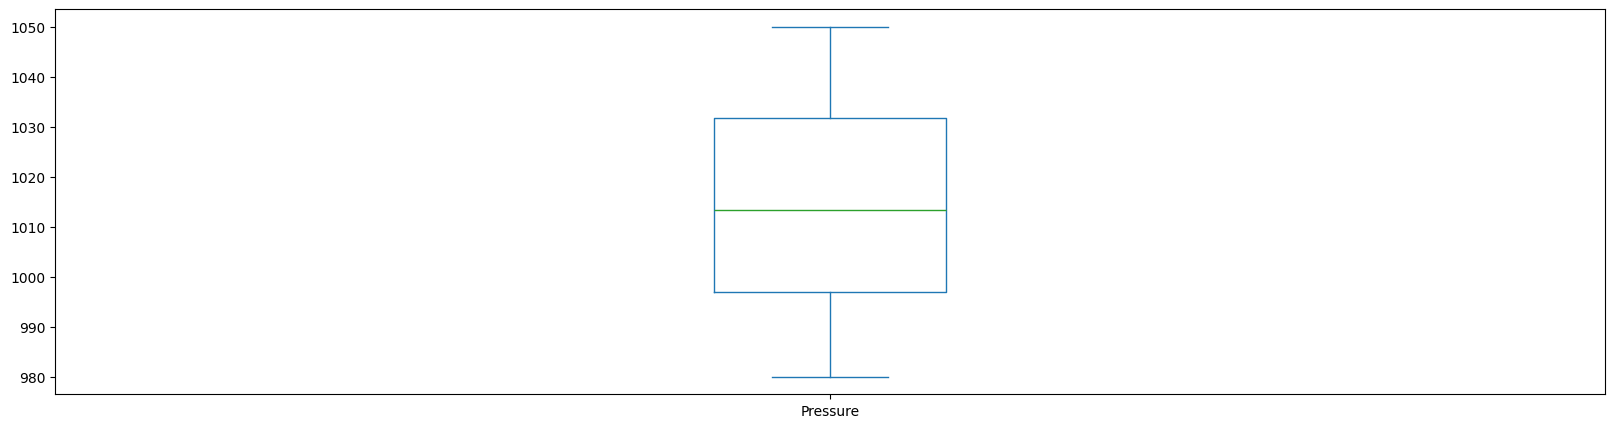

In [15]:
# check outliers
for out in numCols:
        plt.figure(figsize=(20,5))
        weather[out].plot(kind="box")

In [17]:
# check skewness
for skew in numCols:
    skewness=weather[skew].skew()
    print(skewness)

0.007618604325515087
0.04910703372687981
0.001099742391592177
-0.014710527157822659
0.05408319915373729


In [22]:
# split 
x=weather.drop(columns=['Rain'])
y=weather['Rain']
xTrain,xTest,yTrain,yTest=train_test_split(x,y,test_size=0.20,random_state=34)


In [24]:
# encode targe var
label=LabelEncoder()
yTrain=label.fit_transform(yTrain)

In [25]:
yTest=label.transform(yTest)

In [28]:
xT=pd.DataFrame(xTrain)

In [29]:
yT=pd.DataFrame(yTrain)

In [36]:
xtframe=pd.concat([xT.reset_index(drop=True),yT.reset_index(drop=True)],axis=1)
xtframe.corr()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,0
Temperature,1.000000,-0.016098,-0.027779,0.010854,0.000867,-0.262065
Humidity,-0.016098,1.000000,0.007095,-0.009118,-0.032607,0.375636
Wind_Speed,-0.027779,0.007095,1.000000,0.005831,0.025784,0.000246
Cloud_Cover,0.010854,-0.009118,0.005831,1.000000,0.008491,0.324987
Pressure,0.000867,-0.032607,0.025784,0.008491,1.000000,-0.000595
0,-0.262065,0.375636,0.000246,0.324987,-0.000595,1.000000


In [40]:
model=XGBClassifier(

    n_estimators=1290,
    learning_rate=0.1,
reg_lambda=0.1,
reg_alpha=0.1,
    
)
model.fit(xTrain,yTrain)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [41]:
# predict target
myprediction=model.predict(xTest)

In [44]:
# extract class report
classRe=classification_report(yTest,myprediction,target_names=label.classes_,output_dict=True)

In [ ]:
dfRe